--- EAGLEEYE-1 COMMS VISIBILITY ANALYSIS ---
Minimum Elevation Angle: 10.0 deg
Max Pass Duration:       7.38 minutes
--------------------------------------------


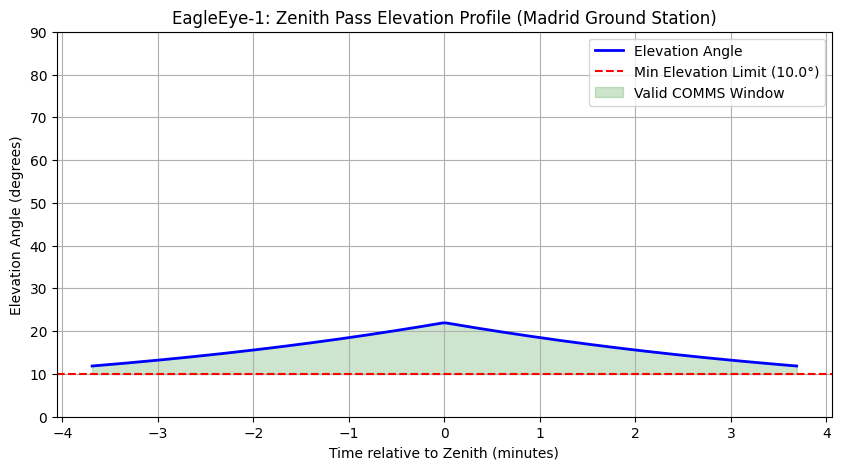

In [2]:
# COMMS: Ground Station Visibility and Pass Duration
# EagleEye-1 Mission

import numpy as np
import matplotlib.pyplot as plt

# 1. CONSTANTS AND ORBITAL PARAMETERS
R_EARTH_KM = 6371.0
ALTITUDE_KM = 500.0
MU_EARTH = 398600.4418
ORBIT_RADIUS_KM = R_EARTH_KM + ALTITUDE_KM

# Ground Station (Madrid, Spain) - Reference only for context in this geometric model
# A full propagator would use exact Lat/Lon, here we calculate the maximum overhead pass
MIN_ELEVATION_DEG = 10.0 

# Calculate Orbital Period (reused from physics module)
period_sec = 2 * np.pi * np.sqrt((ORBIT_RADIUS_KM**3) / MU_EARTH)
period_min = period_sec / 60.0
mean_motion_rad_s = np.sqrt(MU_EARTH / (ORBIT_RADIUS_KM**3)) # Angular velocity

# 2. GEOMETRIC VISIBILITY CALCULATION (Earth Central Angle)
# Convert elevation to radians
eps_rad = np.deg2rad(MIN_ELEVATION_DEG)

# Nadir angle (eta) using Law of Sines
sin_eta = (R_EARTH_KM / ORBIT_RADIUS_KM) * np.cos(eps_rad)
eta_rad = np.arcsin(sin_eta)

# Earth Central Angle (lambda)
lambda_rad = (np.pi / 2.0) - eps_rad - eta_rad

# Maximum visibility time for a direct overhead pass (Seconds)
# Time = (Distance or Arc) / (Velocity)
max_visibility_sec = (2 * lambda_rad) / mean_motion_rad_s
max_visibility_min = max_visibility_sec / 60.0

print(f"--- EAGLEEYE-1 COMMS VISIBILITY ANALYSIS ---")
print(f"Minimum Elevation Angle: {MIN_ELEVATION_DEG} deg")
print(f"Max Pass Duration:       {max_visibility_min:.2f} minutes")
print(f"--------------------------------------------")

# 3. VISUALIZATION: ELEVATION ANGLE OVER TIME
# Simulating a direct overhead pass from AOS (Acquisition of Signal) to LOS (Loss of Signal)
time_array = np.linspace(-max_visibility_sec/2, max_visibility_sec/2, 200)

# Calculate elevation angle at each time step
# Assuming constant angular velocity across the sky for a direct zenith pass
current_lambda = mean_motion_rad_s * time_array

# Calculamos el argumento interno
arg_arccos = np.sin(np.abs(current_lambda)) * (ORBIT_RADIUS_KM / R_EARTH_KM) + np.cos(np.abs(current_lambda))

# Forzamos los límites a [-1.0, 1.0] para evitar errores de precisión de coma flotante
arg_arccos = np.clip(arg_arccos, -1.0, 1.0)

# Calculamos la matriz final de forma segura
elevation_array = np.arccos(arg_arccos)

# Convert variables for plotting
elevation_deg = np.rad2deg((np.pi/2) - np.abs(current_lambda) - np.arcsin((R_EARTH_KM/ORBIT_RADIUS_KM)*np.sin((np.pi/2) + np.abs(current_lambda))))
# Clean up physical limits (only show above 0)
elevation_deg = np.where(elevation_deg < 0, 0, elevation_deg)

plt.figure(figsize=(10, 5))
plt.plot(time_array / 60.0, elevation_deg, 'b-', linewidth=2, label='Elevation Angle')
plt.axhline(y=MIN_ELEVATION_DEG, color='r', linestyle='--', label=f'Min Elevation Limit ({MIN_ELEVATION_DEG}°)')

# Fill the usable communication window
plt.fill_between(time_array / 60.0, MIN_ELEVATION_DEG, elevation_deg, 
                 where=(elevation_deg >= MIN_ELEVATION_DEG), 
                 color='green', alpha=0.2, label='Valid COMMS Window')

plt.title('EagleEye-1: Zenith Pass Elevation Profile (Madrid Ground Station)')
plt.xlabel('Time relative to Zenith (minutes)')
plt.ylabel('Elevation Angle (degrees)')
plt.grid(True)
plt.legend(loc='upper right')
plt.ylim(0, 90)
plt.show()